# Training Summary

Aggregates metrics from Mask2Former training runs in `output/` and renders cross-variant comparisons.

**Sync from HPC**: a keep-list in `.gitignore` tracks only the lightweight artifacts (`metrics.json`, `log.txt`, `inference/coco_instances_results.json`, etc.) — checkpoints (`*.pth`) and `vis/` overlays are excluded. On HPC: `git add output/ && git commit && git push`. Locally: `git pull`.

**Which runs are shown**: edit the `RUNS` allowlist in cell 2.

In [47]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("output")
assert OUTPUT_DIR.exists(), f"{OUTPUT_DIR.resolve()} not found - run from repo root"

for d in sorted(p for p in OUTPUT_DIR.iterdir() if p.is_dir()):
    print(d)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

output/rgb_mi5000_newmap_swin_tiny
output/rgb_mi8000_cos_sz1280_swin_tiny
output/rgb_mi8000_sz1280_fold0of5_seed42_swin_tiny
output/rgb_mi8000_sz1280_fold1of5_seed42_swin_tiny
output/rgb_mi8000_sz1280_fold2of5_seed42_swin_tiny
output/rgb_mi8000_sz1280_fold3of5_seed42_swin_tiny
output/rgb_mi8000_sz1280_fold4of5_seed42_swin_tiny
output/rgb_mi8000_sz1280_sz1280_swin_tiny
output/rgb_papple_mi30000_sz1024_sz1024_swin_tiny
output/rgb_swin_tiny
output/rgbd_dca_1iter_swin_tiny
output/rgbd_dca_iter0_gw2_0_mi5000_swin_tiny
output/rgbd_dca_iter0_mi24000_sz1280_swin_tiny
output/rgbd_dca_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_fold0of5_seed42_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_fold1of5_seed42_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_fold2of5_seed42_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_fold3of5_seed42_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_fold4of5_seed42_swin_tiny
output/rgbd_dca_iter0_mi8000_sz1280_sz1280_swin_tiny
output/rgbd_dc

## Run allowlist

Set the **`DATASET`** trigger below to pick which dataset's runs to load — `"rob2pheno"` or `"papple"`. Each dataset has its own display-name → directory-name map in `RUNS_BY_DATASET`. Comment out a line to drop a run from every table and plot below.

Per-class AP (red/green fruit) is auto-detected: it only exists for `rob2pheno`, so those table columns and the per-class plots appear for `rob2pheno` and are skipped for `papple`.

In [48]:
# Choose which dataset's runs to summarise.
DATASET = "rob2pheno"   # "rob2pheno" or "papple"

RUNS_BY_DATASET = {
    "papple": {
        "rgb": "rgb_papple_mi30000_sz1024_sz1024_swin_tiny",
        "rgbd_early_old": "rgbd_early_papple_mi30000_sz1024_sz1024_swin_tiny",
        "rgbd_early": "rgbd_early_papple_mi30000_sz1024_fixed_depth_swin_tiny",
        "rgbd_dca (K=0)": "rgbd_dca_papple_iter0_mi30000_sz1024_swin_tiny",
        "rgbd_dca (K=1)": "rgbd_dca_papple_iter1_mi30000_sz1024_swin_tiny",
        "rgbd_dca_mask (K=0)": "rgbd_dca_mask_papple_iter0_mi30000_sz1024_swin_tiny",
        "rgbd_dca_mask (K=1)": "rgbd_dca_mask_papple_iter1_mi30000_sz1024_swin_tiny",
    },
    "rob2pheno": {
        "rgb": "rgb_mi8000_sz1280_sz1280_swin_tiny",
        "rgb (cos)": "rgb_mi8000_cos_sz1280_swin_tiny",

        "rgbd_early": "rgbd_early_mi24000_sz1280_fixed_depth_swin_tiny",
        "rgbd_early (cos)": "rgbd_early_mi8000_cos_sz1280_swin_tiny",

        "rgbd_dca (K=0)": "rgbd_dca_iter0_mi24000_sz1280_swin_tiny",
        "rgbd_dca (K=0, cos)": "rgbd_dca_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny",

        "rgbd_dca (K=1)": "rgbd_dca_iter1_mi24000_sz1280_swin_tiny",
        "rgbd_dca (K=1, cos)": "rgbd_dca_iter1_mi8000_cos_dlr5_0_sz1280_swin_tiny",

        "rgbd_dca (K=2)": "rgbd_dca_iter2_mi24000_sz1280_swin_tiny",
        "rgbd_dca (K=2, cos)": "rgbd_dca_iter2_mi8000_cos_dlr5_0_sz1280_swin_tiny",

        "rgbd_dca_mask (K=0)": "rgbd_dca_mask_iter0_mi8000_sz1280_swin_tiny",
        "rgbd_dca_mask (K=1)": "rgbd_dca_mask_iter1_mi8000_sz1280_swin_tiny",

        "rgbd_dca_rgbinit (K=0, cos)": "rgbd_dca_rgbinit_iter0_mi8000_cos_dlr5_0_sz1280_swin_tiny",

        "rgbd_dca_rgbinit (K=1)": "rgbd_dca_rgbinit_iter1_mi24000_swin_tiny",
        "rgbd_dca_rgbinit (K=1, cos)": "rgbd_dca_rgbinit_iter1_mi8000_cos_dlr5_0_sz1280_swin_tiny",

        "rgbd_dca_rgbinit (K=2)": "rgbd_dca_rgbinit_iter2_mi24000_swin_tiny",
    },
}

assert DATASET in RUNS_BY_DATASET, f"DATASET must be one of {list(RUNS_BY_DATASET)}"
RUNS = dict(RUNS_BY_DATASET[DATASET])

missing = [(name, d) for name, d in RUNS.items() if not (OUTPUT_DIR / d / "metrics.json").exists()]
if missing:
    print("WARNING: metrics.json not found for:")
    for name, d in missing:
        print(f"  - {name}  ({OUTPUT_DIR / d})")

RUNS = {name: d for name, d in RUNS.items() if (OUTPUT_DIR / d / "metrics.json").exists()}
print(f"\n[{DATASET}] {len(RUNS)} runs will be loaded: {list(RUNS)}")


[rob2pheno] 16 runs will be loaded: ['rgb', 'rgb (cos)', 'rgbd_early', 'rgbd_early (cos)', 'rgbd_dca (K=0)', 'rgbd_dca (K=0, cos)', 'rgbd_dca (K=1)', 'rgbd_dca (K=1, cos)', 'rgbd_dca (K=2)', 'rgbd_dca (K=2, cos)', 'rgbd_dca_mask (K=0)', 'rgbd_dca_mask (K=1)', 'rgbd_dca_rgbinit (K=0, cos)', 'rgbd_dca_rgbinit (K=1)', 'rgbd_dca_rgbinit (K=1, cos)', 'rgbd_dca_rgbinit (K=2)']


## Loader

Detectron2 writes `metrics.json` as newline-delimited JSON. Each line is one record — either a training step (has `total_loss`) or an evaluation (has `segm/AP`). We split them into two long-format DataFrames per run.

In [49]:
def load_metrics(run_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read metrics.json (JSONL) and split into (train_df, eval_df)."""
    records = []
    with (run_dir / "metrics.json").open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    train_rows = [r for r in records if "total_loss" in r]
    eval_rows  = [r for r in records if "segm/AP" in r]

    train_df = pd.DataFrame(train_rows).sort_values("iteration").reset_index(drop=True)
    eval_df  = pd.DataFrame(eval_rows).sort_values("iteration").reset_index(drop=True)
    return train_df, eval_df


train_data = {}
eval_data  = {}
for name, dirname in RUNS.items():
    train_data[name], eval_data[name] = load_metrics(OUTPUT_DIR / dirname)
    print(f"{name:20s}  train={len(train_data[name]):4d} rows  eval={len(eval_data[name]):3d} rows  "
          f"max_iter={int(train_data[name]['iteration'].max())}")

rgb                   train= 400 rows  eval=  8 rows  max_iter=7999
rgb (cos)             train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_early            train=1200 rows  eval= 24 rows  max_iter=23999
rgbd_early (cos)      train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca (K=0)        train=1200 rows  eval= 24 rows  max_iter=23999
rgbd_dca (K=0, cos)   train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca (K=1)        train=1200 rows  eval= 24 rows  max_iter=23999
rgbd_dca (K=1, cos)   train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca (K=2)        train=1200 rows  eval= 24 rows  max_iter=23999
rgbd_dca (K=2, cos)   train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca_mask (K=0)   train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca_mask (K=1)   train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca_rgbinit (K=0, cos)  train= 400 rows  eval=  8 rows  max_iter=7999
rgbd_dca_rgbinit (K=1)  train=1200 rows  eval= 24 rows  max_iter=23999
rgbd_dca_rgbinit (K=1, cos)  train

## Summary table

Best-iter (by `segm/AP`) and final-iter eval metrics per run. Max value per column is highlighted.

In [50]:
# Per-class AP columns vary by dataset (rob2pheno has red/greenfruit; papple has none),
# so detect whichever "segm/AP-*" columns are present in the loaded runs.
perclass_cols = sorted({c for df in eval_data.values()
                        for c in df.columns if c.startswith("segm/AP-")})

rows = []
for name, eval_df in eval_data.items():
    if eval_df.empty:
        continue
    best = eval_df.loc[eval_df["segm/AP"].idxmax()]
    final = eval_df.iloc[-1]
    row = {
        "variant":    name,
        "best_iter":  int(best["iteration"]),
        "best_AP":    best["segm/AP"],
        "AP50":       best["segm/AP50"],
        "AP75":       best["segm/AP75"],
    }
    for c in perclass_cols:
        row[c.split("/", 1)[1]] = best[c]   # "segm/AP-redfruit" -> "AP-redfruit"
    row["final_iter"] = int(final["iteration"])
    row["final_AP"]   = final["segm/AP"]
    rows.append(row)

summary = pd.DataFrame(rows).set_index("variant")

num_cols = ["best_AP", "AP50", "AP75"] + [c.split("/", 1)[1] for c in perclass_cols] + ["final_AP"]
summary.style.format("{:.2f}", subset=num_cols) \
             .highlight_max(subset=num_cols, color="lightgreen")

,best_iter,best_AP,AP50,AP75,AP-greenfruit,AP-redfruit,final_iter,final_AP
variant,,,,,,,,
rgb,999,67.66,93.59,78.50,66.44,68.89,8000,64.76
rgb (cos),999,67.24,92.52,77.62,65.80,68.69,8000,65.87
rgbd_early,2999,64.53,91.55,75.83,62.50,66.57,24000,62.26
rgbd_early (cos),1999,66.03,93.31,75.48,63.61,68.45,8000,63.93
rgbd_dca (K=0),1999,64.09,91.69,72.71,62.19,65.99,24000,58.84
"rgbd_dca (K=0, cos)",2999,66.19,93.92,77.08,64.28,68.10,8000,65.03
rgbd_dca (K=1),1999,65.71,92.67,76.60,63.91,67.50,24000,60.12
"rgbd_dca (K=1, cos)",999,64.28,91.78,72.25,62.59,65.96,8000,62.52
rgbd_dca (K=2),999,64.94,92.75,75.03,64.17,65.72,24000,60.62


## AP curves over iterations

One line per variant. AP / AP50 / AP75 as side-by-side panels.

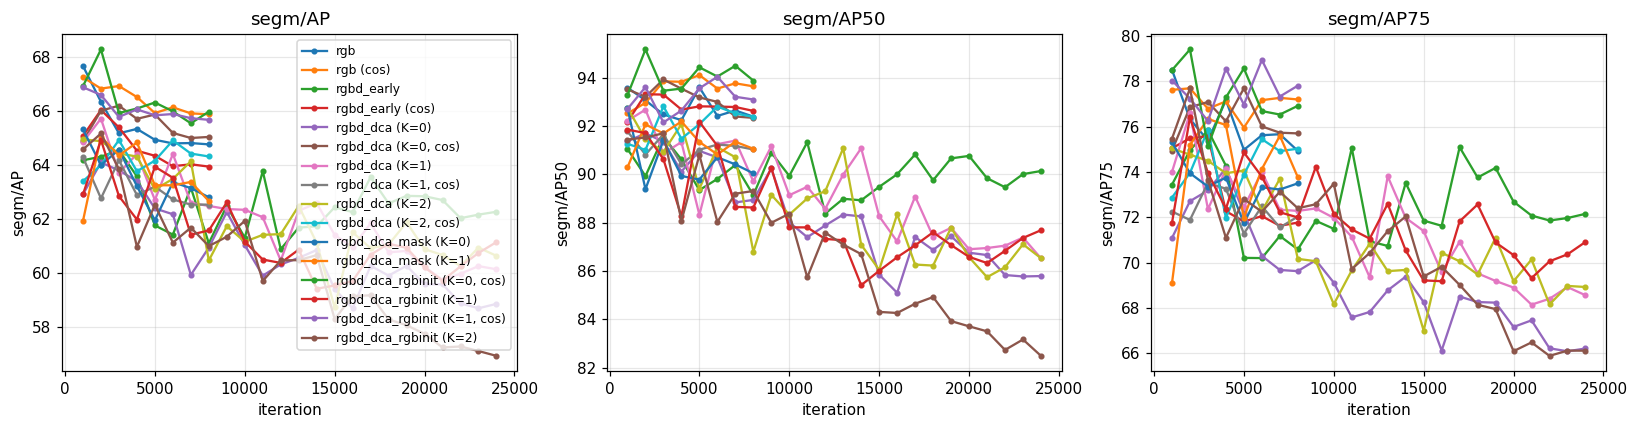

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric in zip(axes, ["segm/AP", "segm/AP50", "segm/AP75"]):
    for name, eval_df in eval_data.items():
        if eval_df.empty:
            continue
        ax.plot(eval_df["iteration"], eval_df[metric], marker="o", markersize=3, label=name)
    ax.set_title(metric)
    ax.set_xlabel("iteration")
    ax.set_ylabel(metric)
axes[0].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

## Per-class AP (red vs green)

Curves over iterations plus a final-iter grouped bar chart.

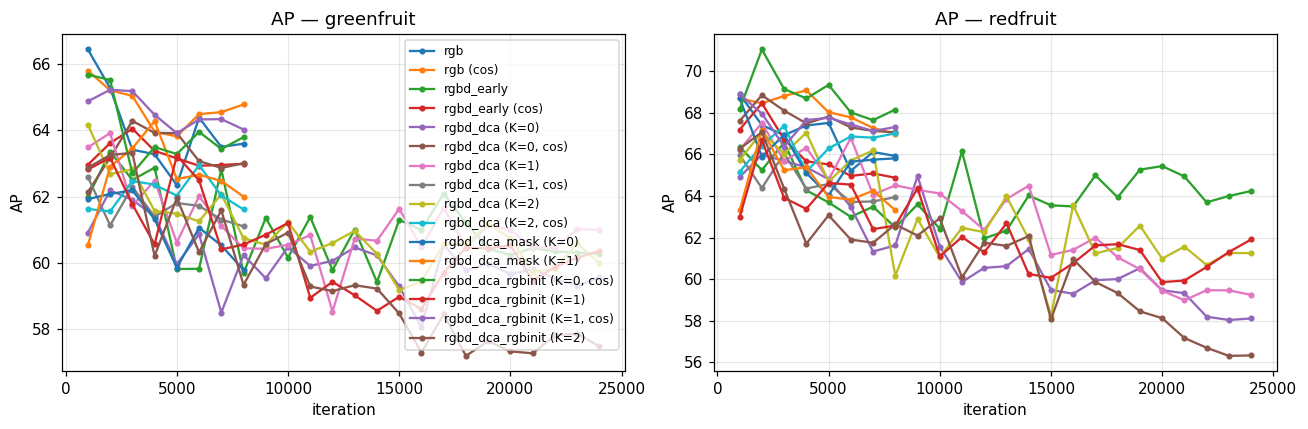

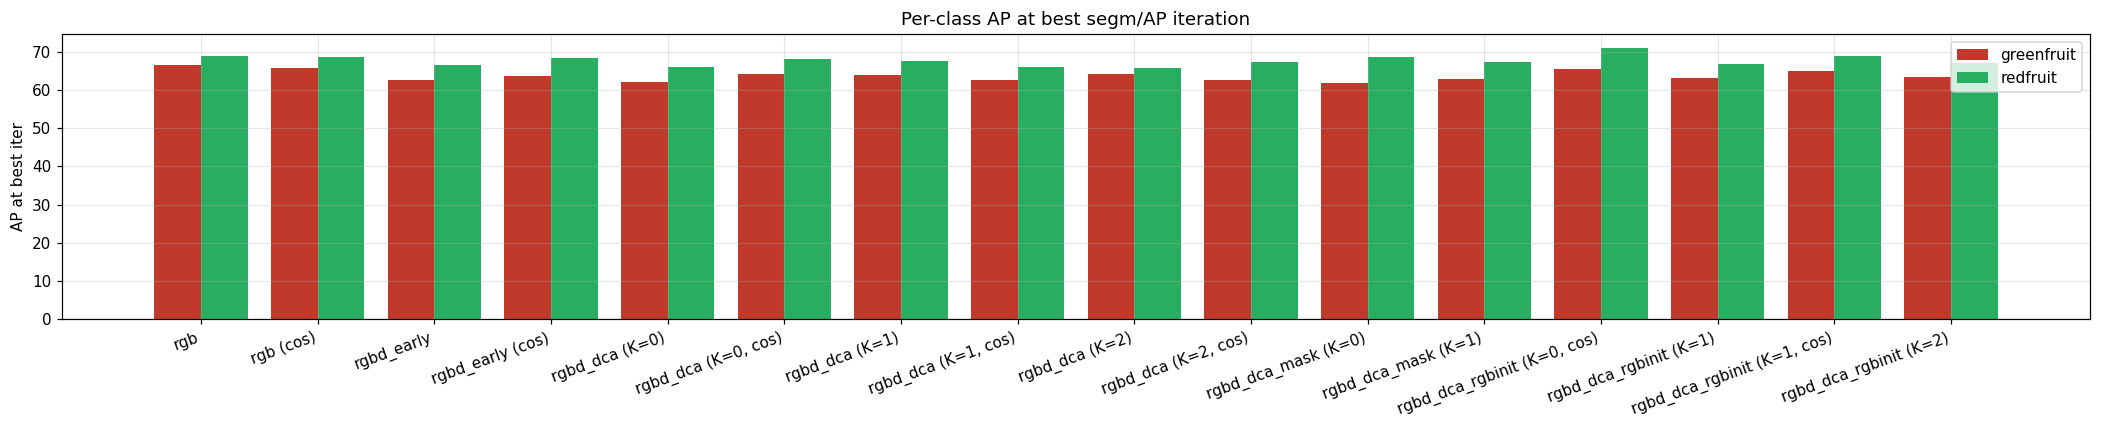

In [52]:
# Per-class metrics only exist for some datasets (e.g. rob2pheno red/greenfruit).
perclass_cols = sorted({c for df in eval_data.values()
                        for c in df.columns if c.startswith("segm/AP-")})

if not perclass_cols:
    print(f"No per-class metrics for dataset '{DATASET}' — skipping per-class plots.")
else:
    palette = ["#c0392b", "#27ae60", "#2980b9", "#8e44ad", "#f39c12"]

    fig, axes = plt.subplots(1, len(perclass_cols),
                             figsize=(6 * len(perclass_cols), 4),
                             sharex=True, squeeze=False)
    for ax, metric in zip(axes[0], perclass_cols):
        for name, eval_df in eval_data.items():
            if eval_df.empty:
                continue
            ax.plot(eval_df["iteration"], eval_df[metric], marker="o", markersize=3, label=name)
        ax.set_title(f"AP — {metric.split('-', 1)[1]}")
        ax.set_xlabel("iteration")
        ax.set_ylabel("AP")
    axes[0][0].legend(fontsize=8, loc="best")
    fig.tight_layout()
    plt.show()

    # Best-iter grouped bar chart, one bar per class per variant
    names = list(summary.index)
    x = np.arange(len(names))
    w = 0.8 / len(perclass_cols)

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(names)), 4))
    for i, metric in enumerate(perclass_cols):
        col = metric.split("/", 1)[1]          # summary column, e.g. "AP-redfruit"
        label = metric.split("-", 1)[1]        # e.g. "redfruit"
        offset = (i - (len(perclass_cols) - 1) / 2) * w
        ax.bar(x + offset, summary[col].values, w, label=label,
               color=palette[i % len(palette)])
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("AP at best iter")
    ax.set_title("Per-class AP at best segm/AP iteration")
    ax.legend()
    fig.tight_layout()
    plt.show()

## Training loss curves

`total_loss`, `loss_ce`, `loss_dice`, `loss_mask`. Per-iter losses are noisy, so a rolling mean (window=50) is overlaid on the raw values.

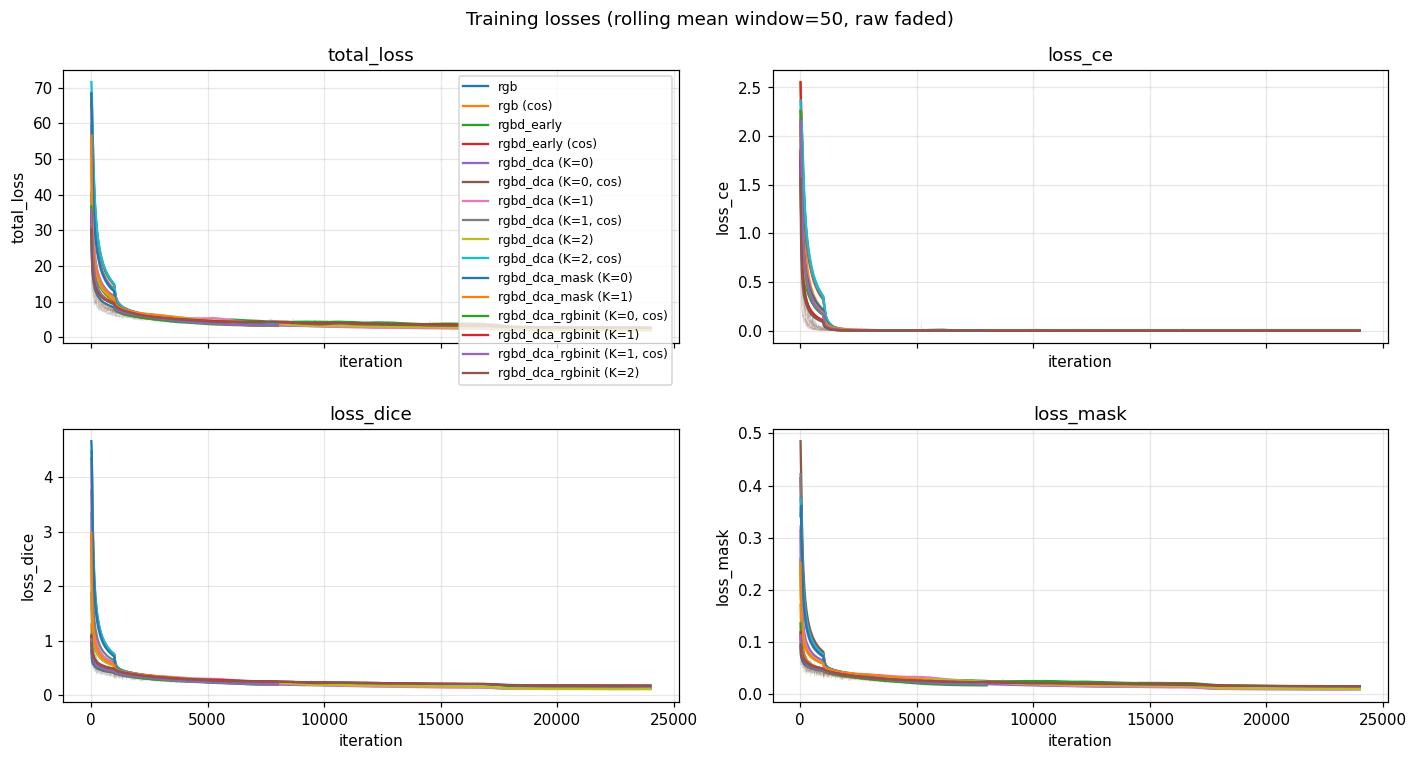

In [53]:
LOSS_COLS = ["total_loss", "loss_ce", "loss_dice", "loss_mask"]
WINDOW = 50

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, col in zip(axes.flat, LOSS_COLS):
    for name, train_df in train_data.items():
        if col not in train_df.columns:
            continue
        smoothed = train_df[col].rolling(WINDOW, min_periods=1).mean()
        line, = ax.plot(train_df["iteration"], smoothed, label=name, linewidth=1.5)
        ax.plot(train_df["iteration"], train_df[col], color=line.get_color(), alpha=0.15, linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel("iteration")
    ax.set_ylabel(col)
axes[0, 0].legend(fontsize=8, loc="best")
fig.suptitle(f"Training losses (rolling mean window={WINDOW}, raw faded)")
fig.tight_layout()
plt.show()

## Final summary bar chart

Grouped bars of best-iter AP / AP50 / AP75 per variant.

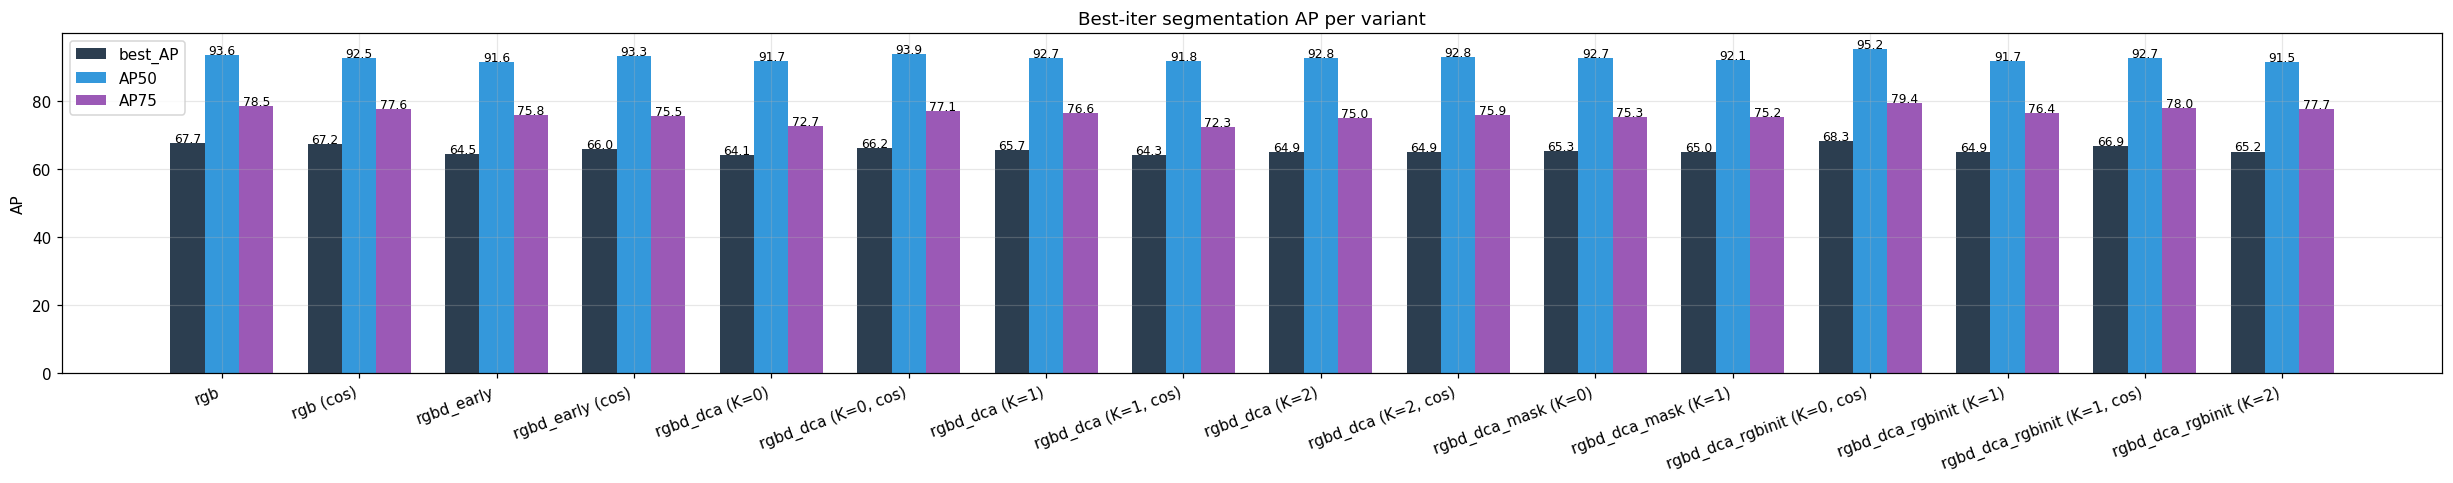

In [54]:
names = list(summary.index)
metrics_to_plot = ["best_AP", "AP50", "AP75"]
colors = ["#2c3e50", "#3498db", "#9b59b6"]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(names)), 4.5))
for i, (m, c) in enumerate(zip(metrics_to_plot, colors)):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, summary[m].values, w, label=m, color=c)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
                f"{b.get_height():.1f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("AP")
ax.set_title("Best-iter segmentation AP per variant")
ax.legend()
fig.tight_layout()
plt.show()

## K-Fold Cross-Validation Summary

Groups all `fold{i}of{k}` directories by their base variant name, extracts the
**best-iteration** metrics per fold (highest `segm/AP`), then plots mean ± 1 std across folds.

In [55]:
# Self-contained setup for the K-Fold section
# (these imports/helpers are also defined earlier in the notebook;
# duplicating here lets you run the section standalone)
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("output")


# Which eval dataset to summarise across folds.
# Fold-specific held-out validation is the right default for k-fold CV.
# Switch to "rob2pheno_val" to use the full validation set instead.
EVAL_DATASET = "rob2pheno_fold_val"


def load_metrics(
    run_dir: Path,
    eval_dataset: str = EVAL_DATASET,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read metrics.json (JSONL) and split into (train_df, eval_df).

    Detectron2 prefixes eval keys with the registered dataset name when
    more than one eval dataset is present, e.g. "rob2pheno_fold_val/segm/AP".
    This loader strips that prefix so downstream code can use the short
    names ("segm/AP", "segm/AP50", ...).
    """
    records = []
    with (run_dir / "metrics.json").open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    train_rows = [r for r in records if "total_loss" in r]
    eval_rows  = [
        r for r in records
        if any(k == "segm/AP" or k.endswith("/segm/AP") for k in r)
    ]

    def _to_df(rows):
        df = pd.DataFrame(rows)
        if df.empty or "iteration" not in df.columns:
            return df
        return df.sort_values("iteration").reset_index(drop=True)

    train_df = _to_df(train_rows)
    eval_df  = _to_df(eval_rows)

    if not eval_df.empty:
        prefix = f"{eval_dataset}/"
        rename = {c: c[len(prefix):] for c in eval_df.columns if c.startswith(prefix)}
        if rename:
            keep_cols = ["iteration"] + list(rename.keys())
            keep_cols = [c for c in keep_cols if c in eval_df.columns]
            eval_df = eval_df[keep_cols].rename(columns=rename)
        # else: columns already use the short form (older runs) - leave as-is

    return train_df, eval_df


def fold_variant_key(dirname: str) -> str:
    """Strip _fold{i}of{k}_seed{s} to get the base variant name."""
    return re.sub(r"_fold\d+of\d+_seed\d+", "", dirname)


# Auto-discover all fold directories in output/
fold_groups: dict[str, list[str]] = {}
for d in sorted(OUTPUT_DIR.iterdir()):
    if d.is_dir() and re.search(r"_fold\d+of\d+", d.name):
        key = fold_variant_key(d.name)
        fold_groups.setdefault(key, []).append(d.name)

print("Discovered fold groups:")
for key, folds in fold_groups.items():
    print(f"  {key}: {len(folds)} folds")
    for f in folds:
        print(f"    - {f}")


Discovered fold groups:
  rgb_mi8000_sz1280_swin_tiny: 5 folds
    - rgb_mi8000_sz1280_fold0of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold1of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold2of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold3of5_seed42_swin_tiny
    - rgb_mi8000_sz1280_fold4of5_seed42_swin_tiny
  rgbd_dca_iter0_mi8000_sz1280_swin_tiny: 5 folds
    - rgbd_dca_iter0_mi8000_sz1280_fold0of5_seed42_swin_tiny
    - rgbd_dca_iter0_mi8000_sz1280_fold1of5_seed42_swin_tiny
    - rgbd_dca_iter0_mi8000_sz1280_fold2of5_seed42_swin_tiny
    - rgbd_dca_iter0_mi8000_sz1280_fold3of5_seed42_swin_tiny
    - rgbd_dca_iter0_mi8000_sz1280_fold4of5_seed42_swin_tiny
  rgbd_dca_iter1_mi8000_sz1280_swin_tiny: 5 folds
    - rgbd_dca_iter1_mi8000_sz1280_fold0of5_seed42_swin_tiny
    - rgbd_dca_iter1_mi8000_sz1280_fold1of5_seed42_swin_tiny
    - rgbd_dca_iter1_mi8000_sz1280_fold2of5_seed42_swin_tiny
    - rgbd_dca_iter1_mi8000_sz1280_fold3of5_seed42_swin_tiny
    - rgbd_dca_iter1_mi8000_sz1280_fol

In [56]:
METRIC_COLS_CV = [
    "segm/AP", "segm/AP50", "segm/AP75",
    "segm/AP-redfruit", "segm/AP-greenfruit",
]

cv_best: dict[str, pd.DataFrame] = {}   # variant -> DataFrame(fold x metric)
cv_eval: dict[str, list[pd.DataFrame]] = {}  # variant -> list of eval_df per fold

for variant, fold_dirs in fold_groups.items():
    best_rows = []
    eval_curves = []
    for dirname in sorted(fold_dirs):
        run_path = OUTPUT_DIR / dirname
        if not (run_path / "metrics.json").exists():
            print(f"  WARNING: missing metrics.json for {dirname}")
            continue
        _, eval_df = load_metrics(run_path)
        if eval_df.empty or "segm/AP" not in eval_df.columns:
            print(f"  WARNING: no segm/AP rows in {dirname}")
            continue

        best_idx = eval_df["segm/AP"].idxmax()
        keep_cols = [c for c in METRIC_COLS_CV if c in eval_df.columns]
        best = eval_df.loc[best_idx, keep_cols + ["iteration"]].to_dict()
        best["fold"] = dirname
        best_rows.append(best)
        eval_curves.append(eval_df)

    if not best_rows:
        print(f"{variant}: no valid folds, skipping")
        continue
    cv_best[variant] = pd.DataFrame(best_rows).set_index("fold")
    cv_eval[variant] = eval_curves
    print(f"{variant}: {len(best_rows)} folds loaded")


rgb_mi8000_sz1280_swin_tiny: 5 folds loaded
rgbd_dca_iter0_mi8000_sz1280_swin_tiny: 5 folds loaded
rgbd_dca_iter1_mi8000_sz1280_swin_tiny: 5 folds loaded
rgbd_dca_iter2_mi8000_sz1280_swin_tiny: 5 folds loaded
rgbd_early_mi8000_sz1280_swin_tiny: 5 folds loaded


In [57]:
if not cv_best:
    raise RuntimeError("cv_best is empty - run the previous cell first or check that output/ contains fold runs")

rows = []
for variant, best_df in cv_best.items():
    row = {"variant": variant}
    for col in METRIC_COLS_CV:
        if col in best_df.columns:
            row[f"{col}_mean"] = best_df[col].mean()
            row[f"{col}_std"]  = best_df[col].std(ddof=1)
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index("variant")

# Build a "mean +/- std" display table
display_df = pd.DataFrame(index=cv_summary.index)
for col in METRIC_COLS_CV:
    m_col, s_col = f"{col}_mean", f"{col}_std"
    if m_col not in cv_summary.columns:
        continue
    display_df[col] = cv_summary.apply(
        lambda r, m=m_col, s=s_col: f"{r[m]:.2f} \u00b1 {r[s]:.2f}", axis=1
    )
display_df


,segm/AP,segm/AP50,segm/AP75,segm/AP-redfruit,segm/AP-greenfruit
variant,,,,,
rgb_mi8000_sz1280_swin_tiny,69.44 ± 1.93,93.80 ± 1.55,81.35 ± 3.31,70.09 ± 3.92,68.80 ± 2.82
rgbd_dca_iter0_mi8000_sz1280_swin_tiny,66.98 ± 1.60,93.45 ± 2.14,77.44 ± 4.13,67.99 ± 2.24,65.97 ± 3.90
rgbd_dca_iter1_mi8000_sz1280_swin_tiny,66.89 ± 1.65,93.07 ± 1.85,77.95 ± 3.60,68.32 ± 2.95,65.46 ± 3.33
rgbd_dca_iter2_mi8000_sz1280_swin_tiny,67.13 ± 1.69,93.32 ± 1.42,78.26 ± 2.05,68.43 ± 2.70,65.83 ± 3.39
rgbd_early_mi8000_sz1280_swin_tiny,66.85 ± 2.33,93.43 ± 1.15,77.00 ± 2.96,67.85 ± 3.15,65.84 ± 3.52


In [58]:
# Best iteration per fold (the eval checkpoint with highest segm/AP)
best_iter_rows = []
for variant, best_df in cv_best.items():
    row = {"variant": variant}
    iters = best_df["iteration"].astype(int)
    # one column per fold index, ordered by fold name
    for fold_name, it in iters.items():
        # extract fold index from e.g. "..._fold2of5_seed42_..."
        import re as _re
        m = _re.search(r"_fold(\d+)of\d+", fold_name)
        col = f"fold{m.group(1)}" if m else fold_name
        row[col] = it
    row["mean"]   = iters.mean()
    row["std"]    = iters.std(ddof=1)
    best_iter_rows.append(row)

best_iter_df = pd.DataFrame(best_iter_rows).set_index("variant")
# Sort fold columns naturally
fold_cols = sorted([c for c in best_iter_df.columns if c.startswith("fold")],
                   key=lambda s: int(s.replace("fold", "")))
best_iter_df = best_iter_df[fold_cols + ["mean", "std"]]

best_iter_df.style.format({**{c: "{:.0f}" for c in fold_cols},
                          "mean": "{:.0f}", "std": "{:.0f}"})


,fold0,fold1,fold2,fold3,fold4,mean,std
variant,,,,,,,
rgb_mi8000_sz1280_swin_tiny,1999,2999,999,999,999,1599,894
rgbd_dca_iter0_mi8000_sz1280_swin_tiny,1999,5999,1999,999,3999,2999,2000
rgbd_dca_iter1_mi8000_sz1280_swin_tiny,999,2999,1999,2999,999,1999,1000
rgbd_dca_iter2_mi8000_sz1280_swin_tiny,999,1999,2999,1999,999,1799,837
rgbd_early_mi8000_sz1280_swin_tiny,1999,1999,999,1999,999,1599,548


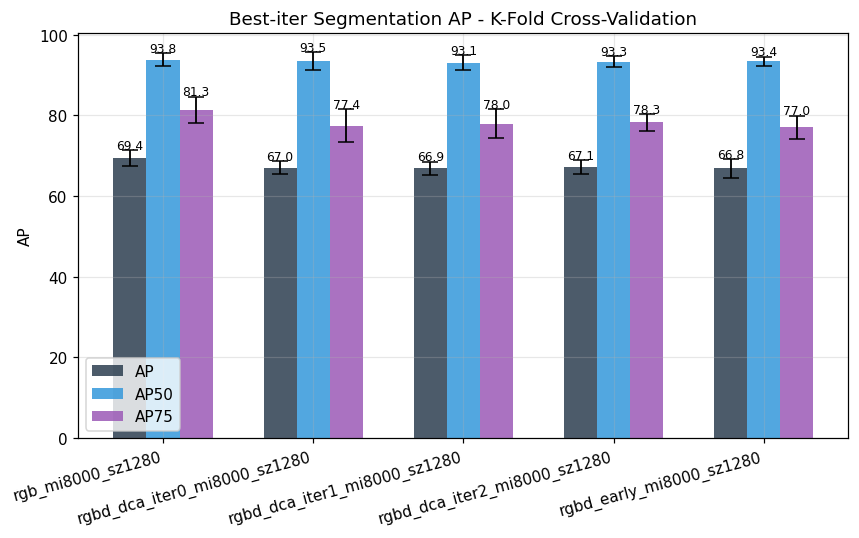

In [59]:
metrics_to_bar = ["segm/AP", "segm/AP50", "segm/AP75"]
variants       = list(cv_summary.index)
x              = np.arange(len(variants))
width          = 0.22
colors_bar     = ["#2c3e50", "#3498db", "#9b59b6"]

fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(variants)), 5))
for i, (metric, color) in enumerate(zip(metrics_to_bar, colors_bar)):
    means = cv_summary[f"{metric}_mean"].values
    stds  = cv_summary[f"{metric}_std"].values
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset, means, width, yerr=stds, capsize=5,
        label=metric.replace("segm/", ""),
        color=color, alpha=0.85, error_kw=dict(elinewidth=1.2)
    )
    for bar, mean_val, std_val in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std_val + 0.3,
            f"{mean_val:.1f}", ha="center", fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels([v.replace("_swin_tiny", "") for v in variants], rotation=15, ha="right")
ax.set_ylabel("AP")
ax.set_title("Best-iter Segmentation AP - K-Fold Cross-Validation")
ax.legend()
fig.tight_layout()
plt.show()


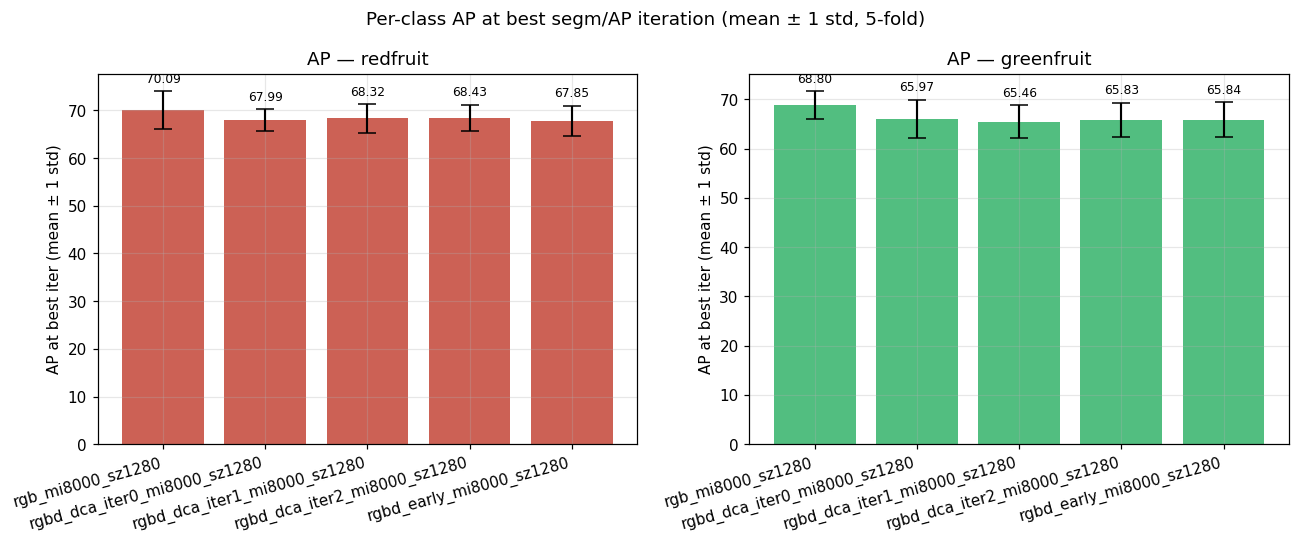

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, metric, title, color in [
    (axes[0], "segm/AP-redfruit",   "AP \u2014 redfruit",   "#c0392b"),
    (axes[1], "segm/AP-greenfruit", "AP \u2014 greenfruit", "#27ae60"),
]:
    means = cv_summary[f"{metric}_mean"].values
    stds  = cv_summary[f"{metric}_std"].values
    bars = ax.bar(
        range(len(variants)), means, yerr=stds, capsize=6,
        color=color, alpha=0.8, error_kw=dict(elinewidth=1.4)
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("AP at best iter (mean \u00b1 1 std)")
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels([v.replace("_swin_tiny", "") for v in variants], rotation=15, ha="right")
fig.suptitle("Per-class AP at best segm/AP iteration (mean \u00b1 1 std, 5-fold)")
fig.tight_layout()
plt.show()


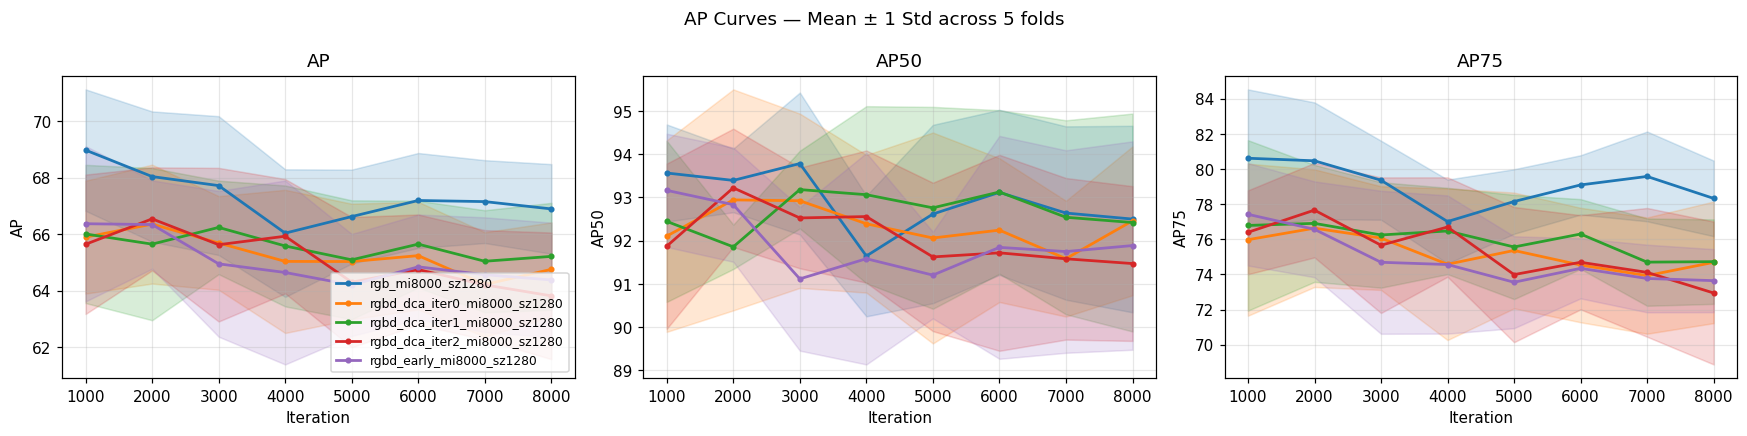

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, metric in zip(axes, ["segm/AP", "segm/AP50", "segm/AP75"]):
    for idx, (variant, fold_dfs) in enumerate(cv_eval.items()):
        color = palette[idx % len(palette)]
        label = variant.replace("_swin_tiny", "")

        # Align curves on common iteration checkpoints
        iters_sets = [set(df["iteration"].values) for df in fold_dfs]
        common_iters = sorted(set.intersection(*iters_sets))

        curves = np.array([
            df.set_index("iteration").loc[common_iters, metric].values
            for df in fold_dfs
        ])  # shape: (n_folds, n_checkpoints)

        mean_curve = curves.mean(axis=0)
        std_curve  = curves.std(axis=0, ddof=1)

        ax.plot(common_iters, mean_curve, color=color, marker="o",
                markersize=3, linewidth=1.8, label=label)
        ax.fill_between(
            common_iters,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color, alpha=0.18
        )

    ax.set_title(metric.replace("segm/", ""))
    ax.set_xlabel("Iteration")
    ax.set_ylabel(metric.replace("segm/", ""))

axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("AP Curves \u2014 Mean \u00b1 1 Std across 5 folds", fontsize=12)
fig.tight_layout()
plt.show()
